In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TRAIN_DATASET_DIR = "./learn_dataset_single_object"  # 学習: 単一物体
TEST_DATASET_DIR  = "./learn_dataset_fixed_angle"     # テスト: 2物体同時
TRAIN_META_CSV = os.path.join(TRAIN_DATASET_DIR, "metadata.csv")
TEST_META_CSV  = os.path.join(TEST_DATASET_DIR,  "metadata.csv")
MODEL_PATH = "./best_detector_agnostic.pt"

N_FIXED = 10

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS     = 20
LR         = 1e-3

D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
print("TRAIN_META_CSV exists:", os.path.exists(TRAIN_META_CSV))
print("TEST_META_CSV  exists:", os.path.exists(TEST_META_CSV))


DEVICE: cpu
TRAIN_META_CSV exists: True
TEST_META_CSV  exists: True


In [3]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [4]:
def physical_to_rd_indices(range_m, velocity_mps, N_trans, sym_duration, lam, Tc, range_offset=620, num_range_bins=190):
    c = 299792458.0
    vel_res = lam / (2.0 * sym_duration * N_trans)
    range_res = c * Tc / 2.0

    d_idx = int(np.round(velocity_mps / vel_res)) % N_trans
    r_idx = int(np.round(range_m / range_res - range_offset))

    valid = (0 <= d_idx < N_trans) and (0 <= r_idx < num_range_bins)
    return d_idx, r_idx, valid

In [5]:
def syntax_check(num, idx, y_value, velocity_value, x_pos):
    idx_list = np.zeros(num, dtype=np.int32)
    position, velocity = np.zeros((num, 3)), np.zeros((num, 3))
    i=0
    s = set()
    while i < num:
        # 初期値における距離間隔を保証するための処理
        if idx+10 in s or idx-10 in s or idx in s: continue
        for j in range(-20,20): s.add(idx+j)
        
        idx_list[i] = idx
        position[i] = np.array([x_pos[idx], y_value, 1])
        # v_cy[i] = np.array([np.random.rand(1)[0]*5.56, 0, 0])
        velocity[i] = np.array([velocity_value, 0, 0])
        
        i+=1
    return idx_list, position, velocity

In [6]:
def get_snapshot_data(cy_idx_target, ve_idx_target,x_pos, p_bs, tx, cy_v_value, ve_v_value, num_cy, num_ve, num_rp, sym_duration, N_trans,Tc, env):
    # Cyclistについて
    cy_idx = np.zeros(num_cy, dtype=np.int32)
    p_cy, v_cy = np.zeros((num_cy, 3)), np.zeros((num_cy, 3))
    # 範囲外アクセスを防ぐための処理
    cy_idx, p_cy, v_cy = syntax_check(num_cy, cy_idx_target, 15, cy_v_value, x_pos)
    n_cy = len(p_cy)
    
    # Vehicleについて
    ve_idx = np.zeros(num_ve, dtype=np.int32)
    p_ve, v_ve = np.zeros((num_ve, 3)), np.zeros((num_ve, 3))
    # 範囲外アクセスを防ぐための処理
    ve_idx, p_ve, v_ve = syntax_check(num_ve, ve_idx_target, 7.5, ve_v_value, x_pos)
    n_ve = len(p_ve)

    # ramppostについて
    p_rp, v_rp = np.zeros((num_rp, 3)), np.zeros((num_rp, 3))
    n_rp = len(p_rp)
    
    # csvファイルの読み込み
    cy_idx += 1
    ve_idx += 1

    P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp = [], [], [], [], [], [], [], [], []
    # 3番目のデータから読み込み開始（最初の数個はノイズのみのため）
    for i in range(len(cy_idx)):
        df = pd.read_csv("./ped/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(cy_idx[i]))
        tstemp_rx_cy.append(np.round((df["Time (s)"]/Tc)).values[3:])
        P_rx_cy.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_cy.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    for i in range(len(ve_idx)):
        df = pd.read_csv("./vehicle/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(ve_idx[i]))
        tstemp_rx_ve.append(np.round((df["Time (s)"].values[3:]/Tc)))
        P_rx_ve.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_ve.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    # 2.545のほうを使う！
    for i in range(2,3):
        df = pd.read_csv("./Ramposts/2.545nano/"+str(i)+"/complex-impulse-response-Run0001-Sensor_0_Tx_0_to_Rx_0.csv")
        tstemp_rx_rp.append(np.round((df["Time (s)"].values[5:]/Tc)))
        P_rx_rp.append(df["| Total Complex Impulse Response total | (W)"].values[5:])
        phase_rp.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[5:])
    phys_quantities = env.phys_quantities(p_bs, p_cy, v_cy, n_cy, p_ve, v_ve, n_ve, p_rp, v_rp, n_rp)
    #print(phys_quantities["relative_velocity"]["cyclists"])
    real_cy_coordinates = []
    real_vel_coordinates = []
    real_rp_coordinates = []

    for i in range(len(p_cy)):
        real_cy_coordinates.append(np.array([p_cy[i][0], p_cy[i][1]]))
    for i in range(len(p_ve)):
        real_vel_coordinates.append(np.array([p_ve[i][0], p_ve[i][1]]))
    for i in range(len(p_rp)):
        real_rp_coordinates.append(np.array([p_rp[i][0], p_rp[i][1]]))
    
        
    ######### We need some functions here. it is like this. read the csv. this outputs the time stemp and corresponding rx value.
    # P_rx_cy_dB = -114
    #P_rx_cy_dB = -111
    #P_rx_ve_dB = -114
    #P_rx_cy_dB = 0
    #P_rx_ve_dB = 0
    
    P_N_dB = -87.98

    Y = env.rx_multiple(tx, P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp, P_N_dB, sym_duration, N_trans)
    
    return Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates

In [7]:
def stevec(N_ant, angle):
    # 入力された角度に対するステアリングベクトルの計算
    resp = (np.arange(N_ant)-N_ant*0.5+0.5).reshape([-1,1])
    resp = np.exp(1j*resp*np.pi*np.sin(angle))
    return np.matrix(resp)

In [8]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [9]:
def FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, sym_duration, lam, Tc, env):
    # ドップラー処理
    Dopp_dft = dft(N_trans)/np.sqrt(N_trans)
    Y_dft = np.zeros((N_trans, N_ant, rx_sample), dtype=np.complex128)
    for i in range(N_ant):
        Y_dft[:,i,:] = Dopp_dft@Y[:,i,:]
    
    final_objects_all = []
    rd_maps = []

    P_range = np.arange(190)+620

    # FFTによる位置推定処理
    tx_arr = np.array(tx) 
    n_fft = 2**(int(rx_sample + N_sample).bit_length())
    #n_fft = 2048
    
    # 窓関数を掛けずにFFTする
    TX_F_all = fft(tx_arr, n=n_fft, axis=1) 
    Y_F_all = fft(Y_dft, n=n_fft, axis=2)
    
    for i in range(len(est_ang)):
        current_angle = est_ang[i]
        ang_rad = current_angle * np.pi / 180
        
        # ステアリングベクトル (N_ant, 1)
        s_vec = np.array(stevec(N_ant, ang_rad))
        
        # --- 周波数領域でのビームフォーミング ---
        
        # 受信信号の合成: Y_combined = sum(Y * s)
        # s_vec を (1, N_ant, 1) に変形して放送
        # Y_F_all: (N_trans, N_ant, n_fft)
        # 重み付け和をとってアンテナ次元を潰す -> (N_trans, n_fft)
        # 修正前
        w_vec = np.conjugate(s_vec).reshape(1, N_ant, 1)
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)
        # 修正後
        w_vec = s_vec.reshape(1, N_ant, 1) 
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)

        # 送信信号(レプリカ)の合成: X_combined = sum(X * s*)
        # 元の数式 g = s* s^H X より、Xにかかる重みは s^H (つまり sの共役)
        # TX_F_all: (N_ant, n_fft)
        s_vec_conj_reshape = np.conjugate(s_vec).reshape(N_ant, 1)
        TX_F_combined = np.sum(TX_F_all * s_vec_conj_reshape, axis=0) # -> (n_fft,)

        # --- 相関演算 (Correlation) ---
        # Correlation = IFFT( FFT(Y) * conj(FFT(X)) )
        # Broadcasting: (N_trans, n_fft) * (n_fft,)
        CORR_f = Y_F_combined * np.conjugate(TX_F_combined)
        
        # 時間領域に戻す
        corr_time = ifft(CORR_f, axis=1)

        # --- 必要な範囲を切り出し ---
        rdresp_single = corr_time[:, P_range]

        # --- 結果保存 ---
        rd_maps.append(rdresp_single.copy())
        rd_maps.append(i)

    return rd_maps

In [10]:
def generate_one_sample(sample_id, target_idx):
    T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env = Radar_setting()
    N_chirp = 89
    N_trans = N_chirp
    tx = env.tx()

    p_bs = np.array([250, -18, 50])
    x_pos = list(np.arange(-450, -149) / 10)

    if TARGET_KIND == "ped":
        num_cy, num_ve, num_rp = 1, 0, 0
        cy_idx_target = int(target_idx)
        ve_idx_target = 128
        cy_v_value, ve_v_value = 6, 10
        target_label = 0
    else:
        num_cy, num_ve, num_rp = 0, 1, 0
        cy_idx_target = 150
        ve_idx_target = int(target_idx)
        cy_v_value, ve_v_value = 6, 10
        target_label = 1

    Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates = get_snapshot_data(
        cy_idx_target, ve_idx_target, x_pos, p_bs, tx,
        cy_v_value, ve_v_value, num_cy, num_ve, num_rp,
        T_symbol, N_trans, Tc, env
    )

    est_ang = MUSIC_method_improved(Y, N_ant, num_cy + num_ve + num_rp, frame_count=sample_id)
    rd_maps = FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, T_symbol, lam, Tc, env)

    target_kinds = []
    target_labels = []
    true_ranges = []
    true_velocities = []
    true_angle_degs = []
    true_d_idx_list = []
    true_r_idx_list = []
    valid_list = []

    for truth_key, kind_name, label_value in [("cyclists", "ped", 0), ("vehicles", "vehicle", 1)]:
        ranges = np.asarray(phys_quantities["range"][truth_key]).reshape(-1)
        velocities = np.asarray(phys_quantities["relative_velocity"][truth_key]).reshape(-1)
        angles_rad = np.asarray(phys_quantities["angle"][truth_key]).reshape(-1)

        n_obj = min(len(ranges), len(velocities), len(angles_rad))
        for i in range(n_obj):
            range_i = float(ranges[i])
            velocity_i = float(velocities[i])
            angle_deg_i = float(np.degrees(angles_rad[i]))
            d_idx_i, r_idx_i, valid_i = physical_to_rd_indices(
                range_i, velocity_i, N_trans, T_symbol, lam, Tc
            )

            target_kinds.append(kind_name)
            target_labels.append(int(label_value))
            true_ranges.append(range_i)
            true_velocities.append(velocity_i)
            true_angle_degs.append(angle_deg_i)
            true_d_idx_list.append(int(d_idx_i))
            true_r_idx_list.append(int(r_idx_i))
            valid_list.append(int(valid_i))

    if len(target_kinds) == 0:
        raise RuntimeError("No targets found in phys_quantities. Check scenario settings.")

    primary_idx = 0
    for i, kind_name in enumerate(target_kinds):
        if kind_name == TARGET_KIND:
            primary_idx = i
            break

    true_range = true_ranges[primary_idx]
    true_velocity = true_velocities[primary_idx]
    true_angle_deg = true_angle_degs[primary_idx]
    d_idx = true_d_idx_list[primary_idx]
    r_idx = true_r_idx_list[primary_idx]
    valid = valid_list[primary_idx]

    save_path = os.path.join(OUTPUT_DIR, f"sample_{sample_id:05d}.npz")
    np.savez_compressed(
        save_path,
        rd_maps=np.array(rd_maps[::2], dtype=np.complex64),
        est_ang=np.array(est_ang, dtype=np.float32),
        true_range=np.float32(true_range),
        true_velocity=np.float32(true_velocity),
        true_angle_deg=np.float32(true_angle_deg),
        true_d_idx=np.int32(d_idx),
        true_r_idx=np.int32(r_idx),
        true_range_list=np.array(true_ranges, dtype=np.float32),
        true_velocity_list=np.array(true_velocities, dtype=np.float32),
        true_angle_deg_list=np.array(true_angle_degs, dtype=np.float32),
        true_d_idx_list=np.array(true_d_idx_list, dtype=np.int32),
        true_r_idx_list=np.array(true_r_idx_list, dtype=np.int32),
        target_labels=np.array(target_labels, dtype=np.int32),
        valid=np.int32(valid),
        valid_list=np.array(valid_list, dtype=np.int32),
        target_label=np.int32(target_label),
        source_index=np.int32(target_idx),
    )

    return {
        "sample_id": sample_id,
        "file": save_path,
        "target_kind": TARGET_KIND,
        "source_index": target_idx,
        "num_angles": len(est_ang),
        "true_range": true_range,
        "true_velocity": true_velocity,
        "true_angle_deg": true_angle_deg,
        "true_d_idx": d_idx,
        "true_r_idx": r_idx,
        "valid": int(valid),
        "num_targets": int(len(target_kinds)),
        "target_kinds_json": json.dumps(target_kinds, ensure_ascii=False),
        "target_labels_json": json.dumps(target_labels),
        "true_range_list_json": json.dumps(true_ranges),
        "true_velocity_list_json": json.dumps(true_velocities),
        "true_angle_deg_list_json": json.dumps(true_angle_degs),
        "true_d_idx_list_json": json.dumps(true_d_idx_list),
        "true_r_idx_list_json": json.dumps(true_r_idx_list),
        "valid_list_json": json.dumps(valid_list),
    }

In [11]:
class MultiTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        npz_path = row["file"]
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join(".", npz_path))

        x = load_all_rd_maps(npz_path)
        H, W = x.shape[1], x.shape[2]

        valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
        valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0

        # 存在するターゲットのみガウスヒートマップ、不在は全ゼロ
        y_cy = make_gaussian_heatmap(H, W, int(row["cyclist_true_d_idx"]), int(row["cyclist_true_r_idx"])) if valid_cy else np.zeros((H, W), dtype=np.float32)
        y_ve = make_gaussian_heatmap(H, W, int(row["vehicle_true_d_idx"]), int(row["vehicle_true_r_idx"])) if valid_ve else np.zeros((H, W), dtype=np.float32)
        y = np.clip(y_cy + y_ve, 0.0, 1.0)[np.newaxis, :]  # (1, H, W)

        return {
            "x": torch.from_numpy(x).float(),
            "y": torch.from_numpy(y).float(),
            "cy_true_d": torch.tensor(int(row["cyclist_true_d_idx"]), dtype=torch.long),
            "cy_true_r": torch.tensor(int(row["cyclist_true_r_idx"]), dtype=torch.long),
            "ve_true_d": torch.tensor(int(row["vehicle_true_d_idx"]), dtype=torch.long),
            "ve_true_r": torch.tensor(int(row["vehicle_true_r_idx"]), dtype=torch.long),
            "valid_cy": torch.tensor(valid_cy, dtype=torch.long),
            "valid_ve": torch.tensor(valid_ve, dtype=torch.long),
        }


In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=N_FIXED, out_channels=2, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(4)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        self.head = nn.Conv2d(fixed_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.head(x)  # logits (B, 2, H, W)

In [13]:
# 学習用: 単一物体データセット
train_all_df = pd.read_csv(TRAIN_META_CSV)
train_all_df = train_all_df[train_all_df["valid_all"] == 1].reset_index(drop=True)

n = len(train_all_df)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

train_df = train_all_df.iloc[:n_train].reset_index(drop=True)
val_df   = train_all_df.iloc[n_train:n_train+n_val].reset_index(drop=True)

# テスト用: 2物体同時データセット
test_df = pd.read_csv(TEST_META_CSV)
test_df = test_df[test_df["valid_all"] == 1].reset_index(drop=True)

print("train:", len(train_df), "  val:", len(val_df), "  test:", len(test_df))
display(train_df.head())


train: 480   val: 60   test: 300


,file,scenario,cyclist_true_d_idx,cyclist_true_r_idx,vehicle_true_d_idx,vehicle_true_r_idx,valid_cyclist,valid_vehicle,valid_all,source_index
0,./learn_dataset_single_object\sample_00000.npz,cyclist_only,1,168,0,0,True,0,1,1
1,./learn_dataset_single_object\sample_00001.npz,cyclist_only,1,168,0,0,True,0,1,2
2,./learn_dataset_single_object\sample_00002.npz,cyclist_only,1,168,0,0,True,0,1,3
3,./learn_dataset_single_object\sample_00003.npz,cyclist_only,1,168,0,0,True,0,1,4
4,./learn_dataset_single_object\sample_00004.npz,cyclist_only,1,167,0,0,True,0,1,5


In [14]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [15]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=1.5, sigma_r=2.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def load_all_rd_maps(npz_path):
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]
    result = []
    for i in range(rd_maps.shape[0]):
        rd_mag = np.abs(rd_maps[i]).astype(np.float32)
        rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
        rd_db = (rd_db - rd_db.mean()) / (rd_db.std() + 1e-6)
        result.append(rd_db)
    return np.stack(result, axis=0)

def decode_peaks_from_logits(logits, threshold=0.8):
    """1chヒートマップから上位2ピークを検出して返す [(d1,r1,conf1),(d2,r2,conf2)]"""
    prob = torch.sigmoid(logits)[0, 0]  # (H, W)
    H, W = prob.shape
    p = prob.clone()
    results = []
    while True:
        flat_idx = torch.argmax(p).item()
        d_idx = flat_idx // W
        r_idx = flat_idx % W
        conf = float(prob[d_idx, r_idx].item())
        if conf < threshold:
            break
        results.append((d_idx, r_idx, conf))
        d0, d1 = max(0, d_idx-3), min(H, d_idx+4)
        r0, r1 = max(0, r_idx-3), min(W, r_idx+4)
        p[d0:d1, r0:r1] = 0.0
    return results

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)


In [16]:
def bce_loss_from_logits(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)

def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    return (1 - num / den).mean()

def compute_loss(logits, targets):
    return bce_loss_from_logits(logits, targets) + dice_loss_from_logits(logits, targets)

def match_peaks_to_targets(peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r):
    import itertools
    if len(peaks) == 0:
        return (-1, -1), (-1, -1)
    if len(peaks) == 1:
        p = peaks[0][:2]
        cy_dist = (p[0]-cy_true_d)**2 + (p[1]-cy_true_r)**2
        ve_dist = (p[0]-ve_true_d)**2 + (p[1]-ve_true_r)**2
        if cy_dist <= ve_dist:
            return p, (-1, -1)
        else:
            return (-1, -1), p
    best_cy, best_ve = peaks[0][:2], peaks[1][:2]
    best_cost = float('inf')
    for p1, p2 in itertools.permutations(peaks[:2]):
        cost = ((p1[0]-cy_true_d)**2 + (p1[1]-cy_true_r)**2 +
                (p2[0]-ve_true_d)**2 + (p2[1]-ve_true_r)**2)
        if cost < best_cost:
            best_cost = cost
            best_cy, best_ve = p1[:2], p2[:2]
    return best_cy, best_ve

def run_epoch(model, loader, optimizer=None, device='cpu'):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    cy_hits, cy_total = 0, 0
    ve_hits, ve_total = 0, 0

    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        cy_true_d = batch['cy_true_d'].cpu().numpy()
        cy_true_r = batch['cy_true_r'].cpu().numpy()
        ve_true_d = batch['ve_true_d'].cpu().numpy()
        ve_true_r = batch['ve_true_r'].cpu().numpy()
        valid_cy  = batch['valid_cy'].cpu().numpy()
        valid_ve  = batch['valid_ve'].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        logits = model(x)
        loss = compute_loss(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            peaks = decode_peaks_from_logits(logits[i:i+1].detach().cpu())
            (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
                peaks, int(cy_true_d[i]), int(cy_true_r[i]),
                int(ve_true_d[i]), int(ve_true_r[i])
            )
            if valid_cy[i]:
                cy_hits  += int(compute_hit(cy_d, cy_r, int(cy_true_d[i]), int(cy_true_r[i])))
                cy_total += 1
            if valid_ve[i]:
                ve_hits  += int(compute_hit(ve_d, ve_r, int(ve_true_d[i]), int(ve_true_r[i])))
                ve_total += 1

    n = len(loader.dataset)
    mean_loss   = total_loss / max(n, 1)
    cy_hit_rate = cy_hits / max(cy_total, 1)
    ve_hit_rate = ve_hits / max(ve_total, 1)
    return mean_loss, cy_hit_rate, ve_hit_rate

In [17]:
train_ds = MultiTargetDataset(train_df)
val_ds   = MultiTargetDataset(val_df)
test_ds  = MultiTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = RadarLightUNet(in_channels=N_FIXED, out_channels=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_cy_hit, train_ve_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss,   val_cy_hit,   val_ve_hit   = run_epoch(model, val_loader,   optimizer=None,      device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_cy_hit": train_cy_hit,
        "train_ve_hit": train_ve_hit,
        "val_loss": val_loss,
        "val_cy_hit": val_cy_hit,
        "val_ve_hit": val_ve_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} cy={train_cy_hit:.3f} ve={train_ve_hit:.3f} | "
        f"val_loss={val_loss:.4f}   cy={val_cy_hit:.3f} ve={val_ve_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

epoch=01 train_loss=1.1473 cy=0.000 ve=0.000 | val_loss=0.8546   cy=0.000 ve=0.000
epoch=02 train_loss=0.7531 cy=0.000 ve=0.000 | val_loss=0.5975   cy=0.000 ve=0.000
epoch=03 train_loss=0.5270 cy=0.547 ve=0.467 | val_loss=0.4543   cy=0.000 ve=0.883
epoch=04 train_loss=0.4035 cy=0.983 ve=0.933 | val_loss=0.4009   cy=0.000 ve=1.000
epoch=05 train_loss=0.3802 cy=0.997 ve=0.972 | val_loss=0.3641   cy=0.000 ve=1.000
epoch=06 train_loss=0.3684 cy=1.000 ve=0.983 | val_loss=0.3729   cy=0.000 ve=0.983
epoch=07 train_loss=0.3632 cy=1.000 ve=1.000 | val_loss=0.3538   cy=0.000 ve=1.000
epoch=08 train_loss=0.3560 cy=1.000 ve=1.000 | val_loss=0.3538   cy=0.000 ve=1.000
epoch=09 train_loss=0.3520 cy=0.997 ve=1.000 | val_loss=0.3514   cy=0.000 ve=1.000
epoch=10 train_loss=0.3475 cy=1.000 ve=1.000 | val_loss=0.3468   cy=0.000 ve=1.000
epoch=11 train_loss=0.3453 cy=1.000 ve=1.000 | val_loss=0.3443   cy=0.000 ve=1.000
epoch=12 train_loss=0.3433 cy=1.000 ve=0.994 | val_loss=0.3433   cy=0.000 ve=1.000
epoc

,epoch,train_loss,train_cy_hit,train_ve_hit,val_loss,val_cy_hit,val_ve_hit
15,16,0.340370,1.0,1.000000,0.341293,0.0,1.0
16,17,0.338726,1.0,1.000000,0.340153,0.0,1.0
17,18,0.338726,1.0,1.000000,0.343128,0.0,1.0
18,19,0.338810,1.0,1.000000,0.342193,0.0,1.0
19,20,0.337830,1.0,0.994444,0.339714,0.0,1.0


In [18]:
best_model = RadarLightUNet(in_channels=N_FIXED, out_channels=1).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_cy_hit, test_ve_hit = run_epoch(best_model, test_loader, optimizer=None, device=DEVICE)
print(f"test_loss={test_loss:.4f}  cyclist_hit={test_cy_hit:.3f}  vehicle_hit={test_ve_hit:.3f}")

test_loss=0.3834  cyclist_hit=0.947  vehicle_hit=0.793


=== sample 0 ===
[detection 1] d=1, r=169, conf=1.000
[detection 2] d=1, r=99, conf=0.998
[true] cyclist=(1,168)  vehicle=(1,99)


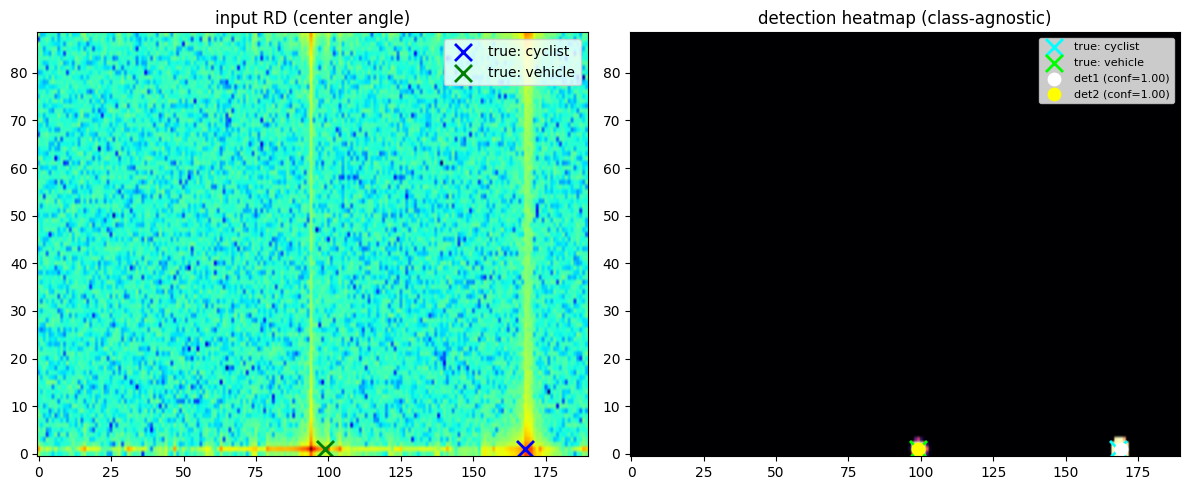

=== sample 1 ===
[detection 1] d=1, r=169, conf=1.000
[detection 2] d=1, r=92, conf=1.000
[true] cyclist=(1,168)  vehicle=(1,91)


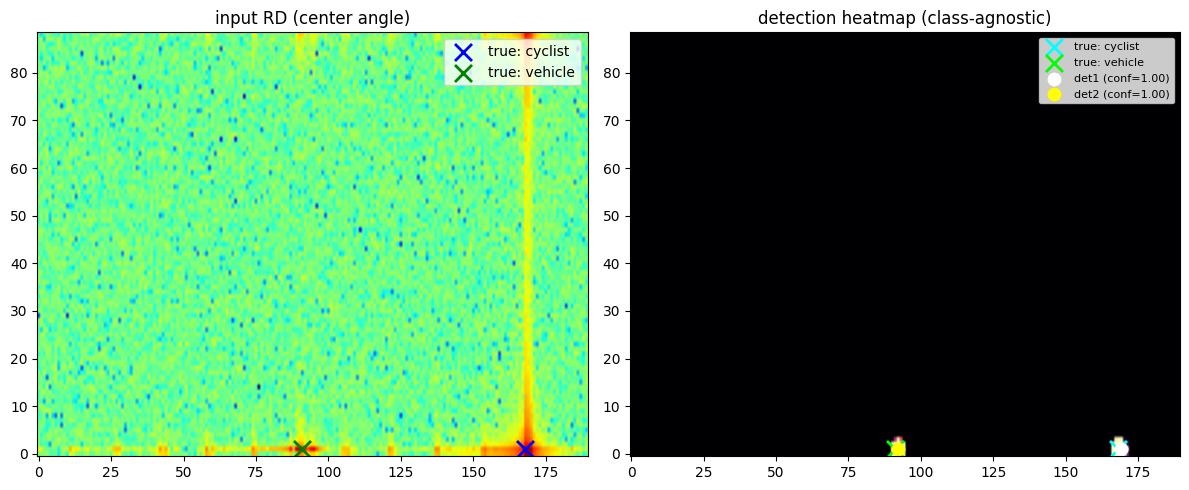

In [19]:
def show_prediction(sample_idx=0):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    peaks = decode_peaks_from_logits(logits.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"=== sample {sample_idx} ===")
    for j, (pd, pr, pc) in enumerate(peaks):
        print(f"[detection {j+1}] d={pd}, r={pr}, conf={pc:.3f}")
    print(f"[true] cyclist=({cy_true_d},{cy_true_r})  vehicle=({ve_true_d},{ve_true_r})")

    rd_db   = x[N_FIXED // 2]
    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()
    colors  = ["white", "yellow", "orange", "red"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    for j, (pd, pr, pc) in enumerate(peaks):
        axes[1].scatter([pr], [pd], c=colors[j % len(colors)], marker="o", s=80, label=f"det{j+1} (conf={pc:.2f})")
    axes[1].set_title("detection heatmap (class-agnostic)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_prediction(sample_idx=0)
show_prediction(sample_idx=1)


In [20]:
def show_failure_pattern(sample_idx, title=""):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # threshold なし

    cy_r = int(row['cyclist_true_r_idx'])
    ve_r = int(row['vehicle_true_r_idx'])
    cy_d = int(row['cyclist_true_d_idx'])
    ve_d = int(row['vehicle_true_d_idx'])
    rd_center = x[N_FIXED // 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}  [sample {sample_idx}]  |cy_r - ve_r| = {abs(cy_r - ve_r)} bins")

    axes[0].imshow(rd_center, aspect='auto', origin='lower', cmap='jet')
    axes[0].plot(cy_r, cy_d, 'bx', ms=10, mew=2, label='true: cyclist')
    axes[0].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    im = axes[1].imshow(prob, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
    axes[1].plot(cy_r, cy_d, 'cx', ms=10, mew=2, label='true: cyclist')
    axes[1].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[1].set_title("heatmap (no threshold)")
    axes[1].legend()
    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()

In [21]:
def collect_predictions(meta_df):
    rows = []
    for i in range(len(meta_df)):
        row = meta_df.iloc[i]
        npz_path = row['file']
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join('.', npz_path))
        x = load_all_rd_maps(npz_path)
        x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
        with torch.no_grad():
            logits = best_model(x_tensor)
        peaks = decode_peaks_from_logits(logits.cpu())

        # ピーク数が可変なのでデフォルト値-1で埋める
        det1_d, det1_r, det1_conf = peaks[0] if len(peaks) > 0 else (-1, -1, 0.0)
        det2_d, det2_r, det2_conf = peaks[1] if len(peaks) > 1 else (-1, -1, 0.0)

        cy_true_d = int(row['cyclist_true_d_idx'])
        cy_true_r = int(row['cyclist_true_r_idx'])
        ve_true_d = int(row['vehicle_true_d_idx'])
        ve_true_r = int(row['vehicle_true_r_idx'])

        (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
            peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r
        )

        rows.append({
            'sample_idx': i,
            'file': row['file'],
            'det1_d': det1_d, 'det1_r': det1_r, 'det1_conf': det1_conf,
            'det2_d': det2_d, 'det2_r': det2_r, 'det2_conf': det2_conf,
            'cy_true_d': cy_true_d, 'cy_true_r': cy_true_r,
            've_true_d': ve_true_d, 've_true_r': ve_true_r,
            'cy_d_err': cy_d - cy_true_d, 'cy_r_err': cy_r - cy_true_r,
            've_d_err': ve_d - ve_true_d, 've_r_err': ve_r - ve_true_r,
            'cy_hit': compute_hit(cy_d, cy_r, cy_true_d, cy_true_r),
            've_hit': compute_hit(ve_d, ve_r, ve_true_d, ve_true_r),
        })
    return pd.DataFrame(rows)

In [22]:
pred_df = collect_predictions(test_df)

print("=== hit rate ===")
print(f"cyclist正解への検出率: {pred_df['cy_hit'].mean():.3f}")
print(f"vehicle正解への検出率: {pred_df['ve_hit'].mean():.3f}")

print("=== cyclist 失敗例 ===")
display(pred_df[pred_df["cy_hit"] == False][["cy_true_d","cy_true_r","det1_d","det1_r","det2_d","det2_r"]].head())
print("=== vehicle 失敗例 ===")
display(pred_df[pred_df["ve_hit"] == False][["ve_true_d","ve_true_r","det1_d","det1_r","det2_d","det2_r"]].head())


=== hit rate ===
cyclist正解への検出率: 0.947
vehicle正解への検出率: 0.793
=== cyclist 失敗例 ===


,cy_true_d,cy_true_r,det1_d,det1_r,det2_d,det2_r
26,1,162,1,165,-1,-1
39,1,158,1,161,-1,-1
45,1,157,1,160,1,111
57,1,154,1,158,-1,-1
60,1,153,1,156,-1,-1


=== vehicle 失敗例 ===


,ve_true_d,ve_true_r,det1_d,det1_r,det2_d,det2_r
5,1,160,1,167,1,90
8,1,162,1,166,-1,-1
13,1,155,1,165,-1,-1
17,1,153,1,164,-1,-1
37,1,159,1,159,-1,-1


r_diff (bins) ごとの失敗集計:
 r_diff   total   ve_fail   ve_fail%   cy_fail   cy_fail%
------------------------------------------------------------
      0       2         2     100.0%         0       0.0%
      1       7         3      42.9%         4      57.1%
      2      10         7      70.0%         2      20.0%
      3       8         4      50.0%         3      37.5%
      4       6         3      50.0%         1      16.7%
      5      11         6      54.5%         1       9.1%
      6       4         2      50.0%         1      25.0%
      7       7         3      42.9%         1      14.3%
      8       8         4      50.0%         1      12.5%
      9       7         1      14.3%         2      28.6%
     10       6         1      16.7%         0       0.0%
     11       7         2      28.6%         0       0.0%
     12       8         2      25.0%         0       0.0%
     13      10         0       0.0%         0       0.0%
     14       2         1      50.0%         0

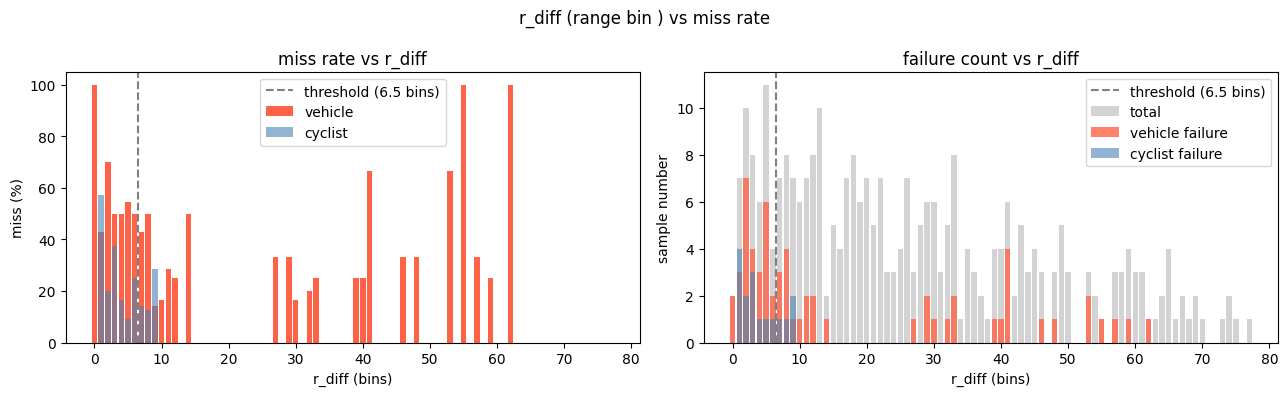

In [23]:
# === 近接失敗ケース: r_diff ごとの失敗数・失敗率 ===
import matplotlib.pyplot as plt
import numpy as np

# 全サンプルにr_diffを付加
pred_df2 = pred_df.copy()
pred_df2['r_diff'] = abs(pred_df2['cy_true_r'] - pred_df2['ve_true_r'])

# r_diff ごとに集計
summary = []
for d in sorted(pred_df2['r_diff'].unique()):
    sub = pred_df2[pred_df2['r_diff'] == d]
    total = len(sub)
    ve_fail = (sub['ve_hit'] == 0).sum()
    cy_fail = (sub['cy_hit'] == 0).sum()
    summary.append({'r_diff': d, 'total': total,
                     've_fail': ve_fail, 'cy_fail': cy_fail,
                     've_fail_rate': ve_fail / total,
                     'cy_fail_rate': cy_fail / total})

import pandas as pd
summary_df = pd.DataFrame(summary)

print('r_diff (bins) ごとの失敗集計:')
print(f'{"r_diff":>7}  {"total":>6}  {"ve_fail":>8}  {"ve_fail%":>9}  {"cy_fail":>8}  {"cy_fail%":>9}')
print('-' * 60)
for _, row in summary_df.iterrows():
    print(f"{int(row['r_diff']):>7}  {int(row['total']):>6}  {int(row['ve_fail']):>8}  {row['ve_fail_rate']*100:>8.1f}%  {int(row['cy_fail']):>8}  {row['cy_fail_rate']*100:>8.1f}%")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('r_diff (range bin ) vs miss rate')

diffs = summary_df['r_diff'].values
axes[0].bar(diffs, summary_df['ve_fail_rate'] * 100, color='tomato', label='vehicle')
axes[0].bar(diffs, summary_df['cy_fail_rate'] * 100, color='steelblue', alpha=0.6, label='cyclist')
axes[0].axvline(6.5, color='gray', linestyle='--', label='threshold (6.5 bins)')
axes[0].set_xlabel('r_diff (bins)')
axes[0].set_ylabel('miss (%)')
axes[0].set_title('miss rate vs r_diff')
axes[0].legend()

axes[1].bar(diffs, summary_df['total'], color='lightgray', label='total')
axes[1].bar(diffs, summary_df['ve_fail'], color='tomato', alpha=0.8, label='vehicle failure')
axes[1].bar(diffs, summary_df['cy_fail'], color='steelblue', alpha=0.6, label='cyclist failure')
axes[1].axvline(6.5, color='gray', linestyle='--', label='threshold (6.5 bins)')
axes[1].set_xlabel('r_diff (bins)')
axes[1].set_ylabel('sample number')
axes[1].set_title('failure count vs r_diff')
axes[1].legend()

plt.tight_layout()
plt.show()


In [24]:
# === r_diff ごとの失敗パターン内訳 (同時/片方) ===
pred_df['r_diff'] = abs(pred_df['cy_true_r'] - pred_df['ve_true_r'])

summary2 = []
for d in sorted(pred_df['r_diff'].unique()):
    sub = pred_df[pred_df['r_diff'] == d]
    total      = len(sub)
    both_fail  = ((sub['ve_hit'] == 0) & (sub['cy_hit'] == 0)).sum()
    only_ve    = ((sub['ve_hit'] == 0) & (sub['cy_hit'] == 1)).sum()
    only_cy    = ((sub['ve_hit'] == 1) & (sub['cy_hit'] == 0)).sum()
    both_ok    = ((sub['ve_hit'] == 1) & (sub['cy_hit'] == 1)).sum()
    if both_fail + only_ve + only_cy > 0:  # 失敗あるr_diffのみ表示
        summary2.append({'r_diff': d, 'total': total,
                         'both_fail': both_fail, 'only_ve': only_ve,
                         'only_cy': only_cy, 'both_ok': both_ok})

import pandas as pd
s2 = pd.DataFrame(summary2)
print(f"{'r_diff':>7}  {'total':>5}  {'両方失敗':>7}  {'ve_only':>7}  {'cy_only':>7}  {'両方成功':>7}")
print("-" * 55)
for _, row in s2.iterrows():
    print(f"{int(row['r_diff']):>7}  {int(row['total']):>5}  "
          f"{int(row['both_fail']):>7}  {int(row['only_ve']):>7}  "
          f"{int(row['only_cy']):>7}  {int(row['both_ok']):>7}")


 r_diff  total     両方失敗  ve_only  cy_only     両方成功
-------------------------------------------------------
      0      2        0        2        0        0
      1      7        0        3        4        0
      2     10        0        7        2        1
      3      8        0        4        3        1
      4      6        0        3        1        2
      5     11        0        6        1        4
      6      4        0        2        1        1
      7      7        0        3        1        3
      8      8        0        4        1        3
      9      7        1        0        1        5
     10      6        0        1        0        5
     11      7        0        2        0        5
     12      8        0        2        0        6
     14      2        0        1        0        1
     27      3        0        1        0        2
     29      6        0        2        0        4
     30      6        0        1        0        5
     32      5        0   

 r_diff  total    n=0    n=1    n=2   cy_min_dr   ve_min_dr
------------------------------------------------------------
      0      2      0      2      0         0.5         0.5
      1      7      0      6      1         0.0         1.0
      2     10      0      9      1         0.5         1.5
      3      8      0      7      1         0.5         1.5
      4      6      0      4      2         1.0         2.5
      5     11      0      7      4         1.0         3.0
      6      4      0      3      1         0.5         4.0
      7      7      0      3      4         1.0         2.0
      8      8      0      4      4         0.0         4.0
      9      7      0      0      7         0.0         0.0
     10      6      0      1      5         0.0         0.5
     11      7      0      2      5         0.0         1.0
     12      8      0      2      6         0.0         1.0
     13     10      0      0     10         0.0         1.0
     14      2      0      1      1    

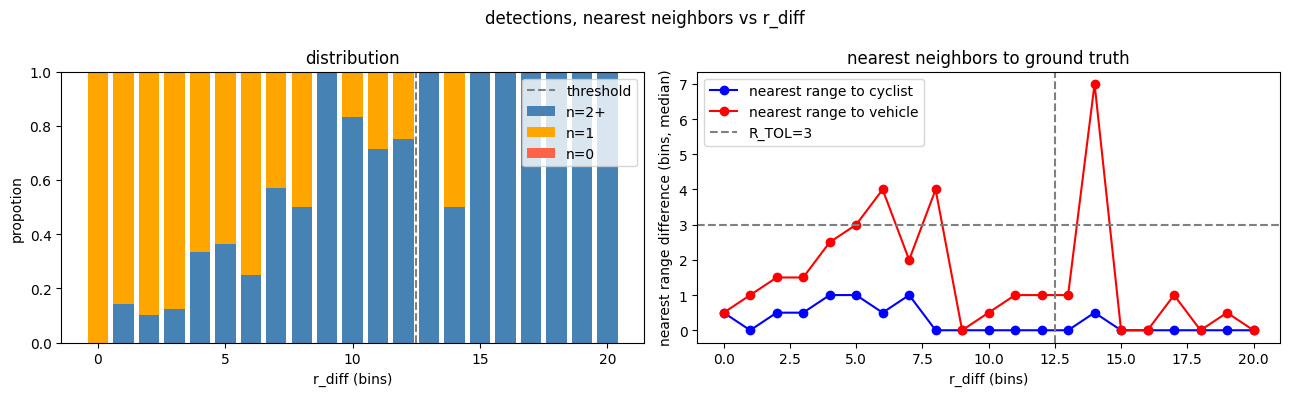

In [29]:
# === 検出数・最近傍距離ベースの分析 ===
import torch, numpy as np, matplotlib.pyplot as plt

pred_df['r_diff'] = abs(pred_df['cy_true_r'] - pred_df['ve_true_r'])

rows = []
for _, row in pred_df.iterrows():
    idx = int(row['sample_idx'])
    npz_path = test_df.iloc[idx]['file']
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join('.', npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())

    cy_r = int(row['cy_true_r']); cy_d = int(row['cy_true_d'])
    ve_r = int(row['ve_true_r']); ve_d = int(row['ve_true_d'])

    # 各真値への最近傍 range 誤差
    if len(peaks) > 0:
        cy_min_dr = min(abs(p[1] - cy_r) for p in peaks)
        ve_min_dr = min(abs(p[1] - ve_r) for p in peaks)
    else:
        cy_min_dr = ve_min_dr = 999

    rows.append({
        'r_diff': int(row['r_diff']),
        'n_peaks': len(peaks),
        'cy_min_dr': cy_min_dr,
        've_min_dr': ve_min_dr,
    })

det_df = pd.DataFrame(rows)

# r_diff ごとに集計 (失敗ゾーンのみ)
print(f"{'r_diff':>7}  {'total':>5}  {'n=0':>5}  {'n=1':>5}  {'n=2':>5}  {'cy_min_dr':>10}  {'ve_min_dr':>10}")
print("-" * 60)
for d in sorted(det_df['r_diff'].unique()):
    sub = det_df[det_df['r_diff'] == d]
    if d > 15:
        continue
    n0 = (sub['n_peaks'] == 0).sum()
    n1 = (sub['n_peaks'] == 1).sum()
    n2 = (sub['n_peaks'] >= 2).sum()
    cy_med = sub['cy_min_dr'].median()
    ve_med = sub['ve_min_dr'].median()
    print(f"{d:>7}  {len(sub):>5}  {n0:>5}  {n1:>5}  {n2:>5}  {cy_med:>10.1f}  {ve_med:>10.1f}")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('detections, nearest neighbors vs r_diff')

# 左: 検出数の割合
diffs = sorted(det_df['r_diff'].unique())
diffs_plot = [d for d in diffs if d <= 20]
n0_rate = [((det_df[det_df['r_diff']==d]['n_peaks']==0).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
n1_rate = [((det_df[det_df['r_diff']==d]['n_peaks']==1).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
n2_rate = [((det_df[det_df['r_diff']==d]['n_peaks']>=2).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
axes[0].bar(diffs_plot, n2_rate, label='n=2+', color='steelblue')
axes[0].bar(diffs_plot, n1_rate, bottom=n2_rate, label='n=1', color='orange')
axes[0].bar(diffs_plot, n0_rate, bottom=[a+b for a,b in zip(n2_rate,n1_rate)], label='n=0', color='tomato')
axes[0].axvline(12.5, color='gray', linestyle='--', label='threshold')
axes[0].set_xlabel('r_diff (bins)'); axes[0].set_ylabel('propotion')
axes[0].set_title('distribution'); axes[0].legend()

# 右: 真値への最近傍距離の中央値
cy_meds = [det_df[det_df['r_diff']==d]['cy_min_dr'].median() for d in diffs_plot]
ve_meds = [det_df[det_df['r_diff']==d]['ve_min_dr'].median() for d in diffs_plot]
axes[1].plot(diffs_plot, cy_meds, 'b-o', label='nearest range to cyclist')
axes[1].plot(diffs_plot, ve_meds, 'r-o', label='nearest range to vehicle')
axes[1].axhline(3, color='gray', linestyle='--', label='R_TOL=3')
axes[1].axvline(12.5, color='gray', linestyle='--')
axes[1].set_xlabel('r_diff (bins)'); axes[1].set_ylabel('nearest range difference (bins, median)')
axes[1].set_title('nearest neighbors to ground truth'); axes[1].legend()

plt.tight_layout()
plt.show()


C:\Users\kousu\AppData\Local\Temp\ipykernel_3836\1539000358.py:65: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_3836\1539000358.py:65: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_3836\1539000358.py:65: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_3836\1539000358.py:65: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_3836\1539000358.py:65: UserWarning: Glyph 12500 (\N{KATAKANA LETTER PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_3836\1539000358.py:65: UserWarning: Glyph 12540 (\N{KATAKANA-HIR

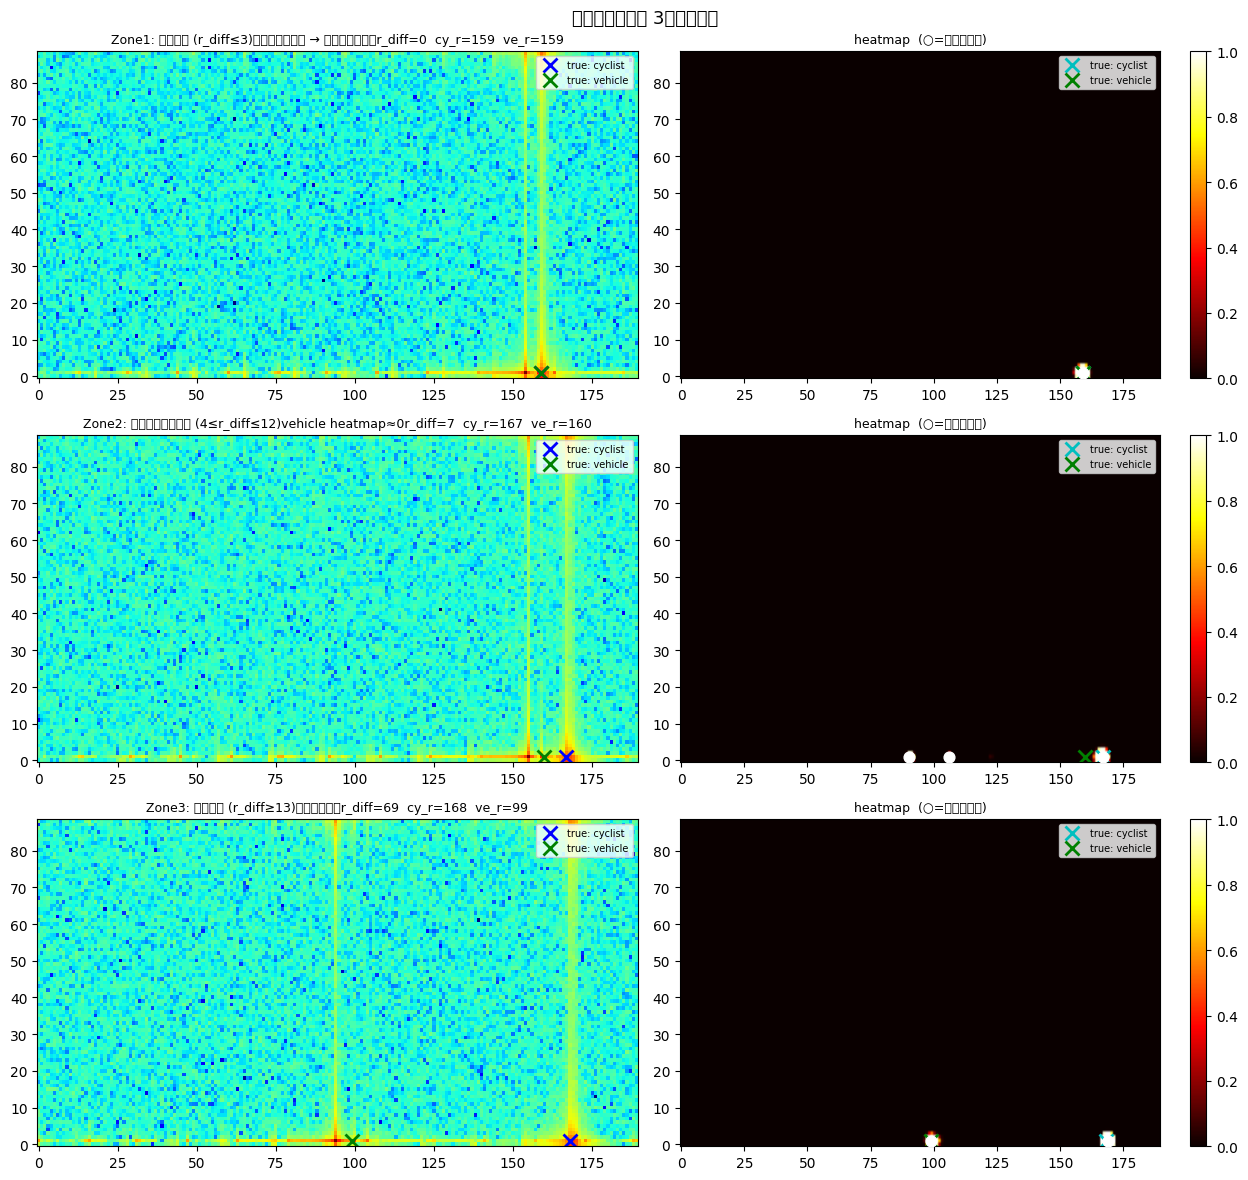

In [26]:
# === 3ゾーン別 失敗メカニズム可視化 ===
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

pred_df['r_diff'] = abs(pred_df['cy_true_r'] - pred_df['ve_true_r'])

def get_rd_and_heatmap(sample_idx):
    row = test_df.iloc[sample_idx]
    npz_path = row['file']
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join('.', npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    rd = x[N_FIXED // 2]
    return rd, prob

# 各ゾーンから1サンプル選択
z1 = pred_df[(pred_df['r_diff'] <= 3) & ((pred_df['ve_hit'] == 0) | (pred_df['cy_hit'] == 0))].iloc[0]
z2 = pred_df[(pred_df['r_diff'] >= 4) & (pred_df['r_diff'] <= 12) & (pred_df['ve_hit'] == 0)].iloc[0]
z3 = pred_df[(pred_df['r_diff'] >= 13) & (pred_df['ve_hit'] == 1) & (pred_df['cy_hit'] == 1)].iloc[0]

zones = [
    (z1, "Zone1: 直接合成 (r_diff≤3)ピーク位置ずれ → マッチング失敗"),
    (z2, "Zone2: サイドローブ重畳 (4≤r_diff≤12)vehicle heatmap≈0"),
    (z3, "Zone3: 完全分離 (r_diff≥13)両方検出成功"),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle('失敗メカニズム 3ゾーン比較', fontsize=13)

for row_i, (row, title) in enumerate(zones):
    idx = int(row['sample_idx'])
    cy_r = int(row['cy_true_r']); cy_d = int(row['cy_true_d'])
    ve_r = int(row['ve_true_r']); ve_d = int(row['ve_true_d'])
    r_diff = int(row['r_diff'])
    rd, prob = get_rd_and_heatmap(idx)
    peaks = decode_peaks_from_logits(
        best_model(torch.from_numpy(load_all_rd_maps(
            os.path.normpath(os.path.join('.', test_df.iloc[idx]['file']))
        )).unsqueeze(0).float().to(DEVICE)).cpu()
    )

    ax_rd = axes[row_i, 0]
    ax_hm = axes[row_i, 1]

    ax_rd.imshow(rd, aspect='auto', origin='lower', cmap='jet')
    ax_rd.plot(cy_r, cy_d, 'bx', ms=10, mew=2, label='true: cyclist')
    ax_rd.plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    ax_rd.set_title(f"{title}r_diff={r_diff}  cy_r={cy_r}  ve_r={ve_r}", fontsize=9)
    ax_rd.legend(fontsize=7)

    im = ax_hm.imshow(prob, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
    ax_hm.plot(cy_r, cy_d, 'cx', ms=10, mew=2, label='true: cyclist')
    ax_hm.plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    for pk_d, pk_r, pk_c in peaks:
        ax_hm.scatter([pk_r], [pk_d], c='white', s=60, zorder=5)
    ax_hm.set_title(f"heatmap  (○=検出ピーク)", fontsize=9)
    ax_hm.legend(fontsize=7)
    plt.colorbar(im, ax=ax_hm)

plt.tight_layout()
plt.show()


In [27]:
# hitサンプルのみで誤差を計算
cy_hit_df = pred_df[pred_df['cy_hit'] == 1]
ve_hit_df = pred_df[pred_df['ve_hit'] == 1]

print("=== 誤差統計 (hit samples only) ===")
err_cols = pd.DataFrame({
    'cy_d_err': cy_hit_df['cy_d_err'],
    'cy_r_err': cy_hit_df['cy_r_err'],
    've_d_err': ve_hit_df['ve_d_err'],
    've_r_err': ve_hit_df['ve_r_err'],
})
print(err_cols.describe().loc[['mean','std','max','min']])


=== 誤差統計 (hit samples only) ===
      cy_d_err  cy_r_err  ve_d_err  ve_r_err
mean       0.0  0.225352       0.0 -0.033613
std        0.0  0.639063       0.0  0.773318
max        0.0  3.000000       0.0  2.000000
min        0.0 -2.000000       0.0 -3.000000


scenario: cyclist_only
det1: d=1, r=169, conf=1.0000


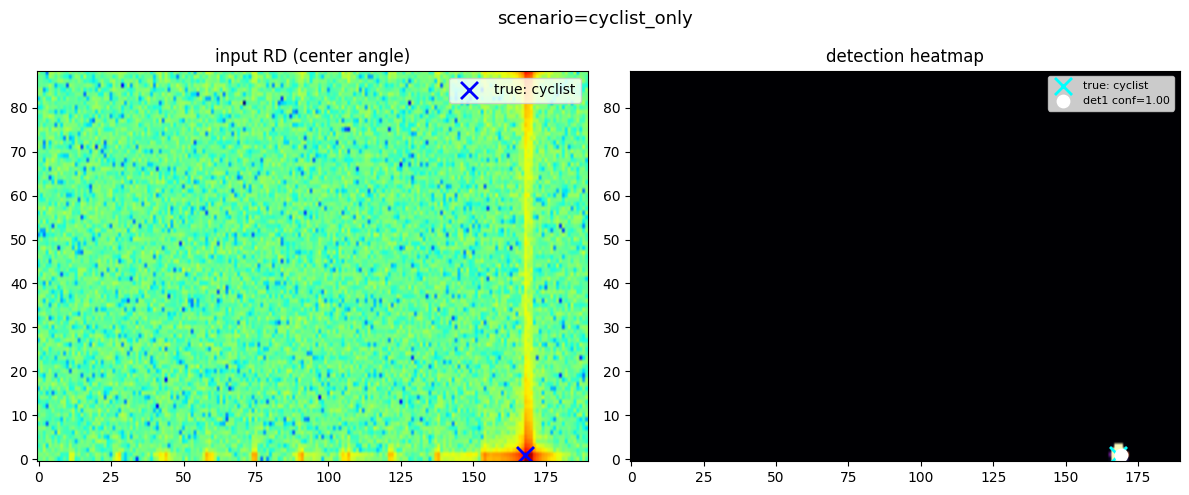

scenario: vehicle_only
det1: d=1, r=99, conf=1.0000


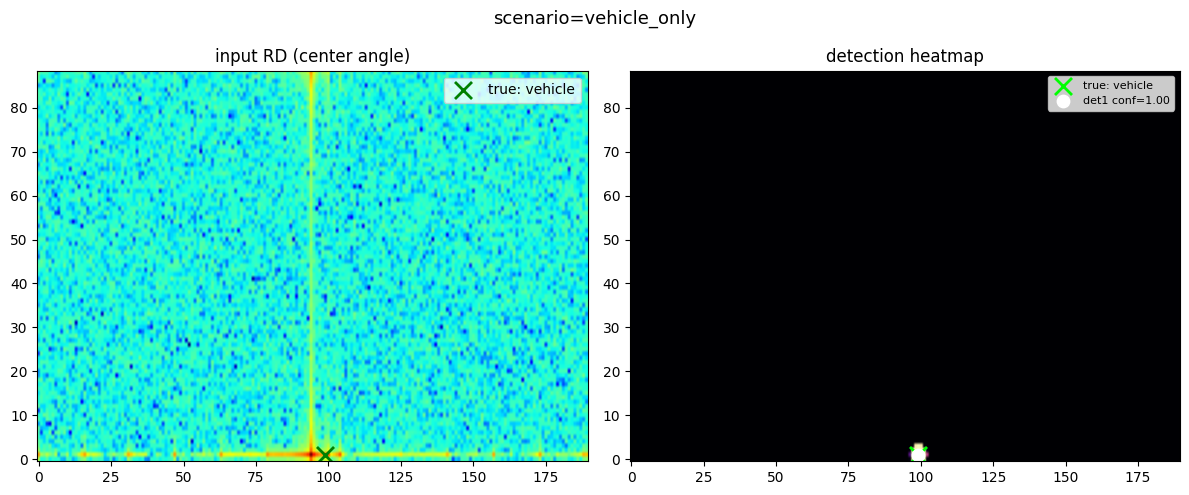

In [28]:
# === 単一物体サンプルでのチャンネル抑制確認 ===
# cyclist_only → ch0にピーク・ch1がフラット になるか
# vehicle_only → ch0がフラット・ch1にピーク になるか

def show_channel_suppression(scenario, sample_idx=0):
    single_df = pd.read_csv("./learn_dataset_single_object/metadata.csv")
    single_df = single_df[single_df["scenario"] == scenario].reset_index(drop=True)
    row = single_df.iloc[sample_idx]

    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()  # (H, W) 1chのみ

    peaks = decode_peaks_from_logits(logits.cpu())

    valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
    valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0
    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"scenario: {scenario}")
    for j, (pk_d, pk_r, pk_c) in enumerate(peaks):
        print(f"det{j+1}: d={pk_d}, r={pk_r}, conf={pk_c:.4f}")

    rd_db = x[N_FIXED // 2]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"scenario={scenario}", fontsize=13)

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    if valid_cy:
        axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    if valid_cy:
        axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    colors = ["white", "yellow", "orange", "red"]
    for j, (pk_d, pk_r, pk_c) in enumerate(peaks):
        axes[1].scatter([pk_r], [pk_d], c=colors[j % len(colors)], marker="o", s=80, label=f"det{j+1} conf={pk_c:.2f}")
    axes[1].set_title("detection heatmap")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_channel_suppression("cyclist_only", sample_idx=0)
show_channel_suppression("vehicle_only", sample_idx=0)
